# FED/Addis Loading Envelope

Clean starter notebook for the narrowed IMPROVE/FED vs Addis/SPARTAN tests.

Scope:
- compare IMPROVE and Addis/ETAD by mass loading and fAbs-derived optical loading;
- identify Addis-like IMPROVE samples;
- keep FED `Ref*` / `Trans*` as auxiliary TOR/carbon-analyzer R/T diagnostics only;
- keep relevant scatter/envelope axes pinned to origin `(0, 0)`.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Find repo root from the current kernel working directory.
cwd = Path.cwd().resolve()
repo_candidates = [cwd, *cwd.parents]
repo_root = next(
    (p for p in repo_candidates if (p / 'research' / 'ftir_hips_chem' / 'scripts').exists()),
    Path('/Users/ahmadjalil/github/aethmodular'),
)

scripts_dir = repo_root / 'research' / 'ftir_hips_chem' / 'scripts'
if str(scripts_dir) not in sys.path:
    sys.path.insert(0, str(scripts_dir))

from plotting import apply_default_style
apply_default_style()

NOTEBOOK_DIR = repo_root / 'research' / 'improve_hips_offset' / 'next_tests_2026_04'
OUTPUT_DIR = NOTEBOOK_DIR / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)

FED_DIR = repo_root / 'research' / 'improve_hips_offset' / 'output' / 'improve_first_order_loading_range_analysis'
LEGACY_FED_DIR = repo_root / 'research' / 'ftir_hips_chem' / 'output' / 'improve_high_fabs_comparison'
FILTER_DATA = repo_root / 'research' / 'ftir_hips_chem' / 'Filter Data' / 'unified_filter_dataset.csv'

IMPROVE_AREA_CM2 = 3.53

print(f'Repo root: {repo_root}')
print(f'Output: {OUTPUT_DIR}')

Repo root: /Users/ahmadjalil/github/aethmodular
Output: /Users/ahmadjalil/github/aethmodular/research/improve_hips_offset/next_tests_2026_04/output


## Plot Helpers

`set_origin_zero` is the default for scatter/envelope plots where a nonzero origin would distort the loading comparison.

In [2]:
def set_origin_zero(ax, x=None, y=None, pad=0.05):
    """Pin axes at (0, 0) and pad the positive range."""
    if x is None:
        xmax = ax.get_xlim()[1]
    else:
        xmax = pd.Series(x).replace([np.inf, -np.inf], np.nan).max()
    if y is None:
        ymax = ax.get_ylim()[1]
    else:
        ymax = pd.Series(y).replace([np.inf, -np.inf], np.nan).max()

    xmax = 1 if pd.isna(xmax) or xmax <= 0 else xmax * (1 + pad)
    ymax = 1 if pd.isna(ymax) or ymax <= 0 else ymax * (1 + pad)
    ax.set_xlim(0, xmax)
    ax.set_ylim(0, ymax)
    return ax


def savefig(fig, name):
    path = OUTPUT_DIR / name
    fig.savefig(path, dpi=160, bbox_inches='tight')
    print(path)
    return path

## Load Existing Data Products

This notebook reads table products only. It does not import older notebooks.

In [3]:
improve_all_path = LEGACY_FED_DIR / 'improve_valid_cleaned.csv'
candidate_path = FED_DIR / 'all_bounds_p05p95_rows.csv'
bounds_path = FED_DIR / 'etad_reference_bounds.csv'

if not improve_all_path.exists():
    improve_all_path = repo_root / 'research' / 'improve_hips_offset' / 'output' / 'improve_hips_offset_narrative' / 'improve_valid_positive.csv'

improve_all = pd.read_csv(improve_all_path, parse_dates=['Date'])
improve_candidates = pd.read_csv(candidate_path, parse_dates=['Date']) if candidate_path.exists() else pd.DataFrame()
bounds = pd.read_csv(bounds_path) if bounds_path.exists() else pd.DataFrame()

print('Full IMPROVE table:', improve_all_path)
print(improve_all.shape)
print('Addis-like candidate table:', candidate_path if candidate_path.exists() else 'not found')
print(improve_candidates.shape)
display(improve_all.head())
display(bounds)

Full IMPROVE table: /Users/ahmadjalil/github/aethmodular/research/ftir_hips_chem/output/improve_high_fabs_comparison/improve_valid_cleaned.csv
(379697, 48)
Addis-like candidate table: /Users/ahmadjalil/github/aethmodular/research/improve_hips_offset/output/improve_first_order_loading_range_analysis/all_bounds_p05p95_rows.csv
(10, 51)


/var/folders/7k/65ckdzsj0w3171qv80rh8dgr0000gn/T/ipykernel_54815/3339726626.py:8: DtypeWarning: Columns (38,46) have mixed types. Specify dtype option on import or set low_memory=False.
  improve_all = pd.read_csv(improve_all_path, parse_dates=['Date'])


,Dataset,SiteCode,POC,Date,AuxID,ECf_Val,OCf_Val,fAbs_Val,FlowRate_Val,FEf_Val,...,DemographicCode,Sponsor,RefF_635_Val,TransF_635_Val,RefI_635_Val,TransI_635_Val,RefM_635_Val,TransM_635_Val,rt_source_file,rt_available
0,IMPAER,BIRM1,1,2005-07-24,0,2.6324,7.5017,12.86,NaN,NaN,...,NaN,STM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,IMPAER,CABA1,1,2005-06-15,0,0.0655,0.0900,0.61,NaN,NaN,...,NaN,STATE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
2,IMPAER,CACO1,1,2005-01-13,0,0.2468,0.7252,2.24,NaN,NaN,...,NaN,STATE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
3,IMPAER,CACR1,1,2005-12-21,0,0.6859,1.8910,4.79,NaN,NaN,...,NaN,USFS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
4,IMPAER,CACR1,1,2005-12-24,0,0.2039,0.7531,2.19,NaN,NaN,...,NaN,USFS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False


,metric,n,min,p05,p25,median,p75,p95,max
0,fAbs_Mm-1,190,28.085699,34.680930,41.281968,47.132129,55.707245,68.043457,85.852735
1,EC_ug_m3,190,0.693115,2.364730,3.295147,4.624584,6.638418,9.600472,11.735113
2,EC_loading_ug_filter,190,4.870656,16.679911,23.874623,33.503921,47.618633,69.329343,82.464986
3,EC_loading_ug_cm2,190,1.379789,4.725187,6.763349,9.491196,13.489698,19.640041,23.361186


## Derived Loading Variables

Use actual FED volume when available: `FlowRate_LPM * SampDur_min / 1000`. Keep the Module A deposit area assumption at `3.53 cm2` for IMPROVE surface loading.

In [4]:
def add_loading_metrics(frame):
    frame = frame.copy()
    if frame.empty:
        return frame

    if 'volume_m3' not in frame.columns and {'FlowRate_Val', 'SampDur_Val'}.issubset(frame.columns):
        frame['volume_m3'] = frame['FlowRate_Val'] * frame['SampDur_Val'] / 1000

    for species, conc_col in [('EC', 'ECf_Val'), ('OC', 'OCf_Val'), ('MF', 'MF_Val')]:
        mass_col = f'{species}_loading_ug'
        surface_col = f'{species}_loading_ug_cm2_area_3p53'
        if mass_col not in frame.columns and {conc_col, 'volume_m3'}.issubset(frame.columns):
            frame[mass_col] = frame[conc_col] * frame['volume_m3']
        if surface_col not in frame.columns and mass_col in frame.columns:
            frame[surface_col] = frame[mass_col] / IMPROVE_AREA_CM2

    if 'tau633_from_fAbs' not in frame.columns and {'fAbs_Val', 'volume_m3'}.issubset(frame.columns):
        frame['tau633_from_fAbs'] = frame['fAbs_Val'] * frame['volume_m3'] / (100 * IMPROVE_AREA_CM2)
    return frame


df = add_loading_metrics(improve_all)
candidate_df = add_loading_metrics(improve_candidates)

keep_cols = [c for c in [
    'Date', 'SiteCode', 'SiteName', 'ECf_Val', 'OCf_Val', 'MF_Val', 'fAbs_Val',
    'volume_m3', 'EC_loading_ug', 'EC_loading_ug_cm2_area_3p53',
    'OC_loading_ug_cm2_area_3p53', 'MF_loading_ug_cm2_area_3p53', 'tau633_from_fAbs'
] if c in df.columns]

display(df[keep_cols].describe(include='all'))
print(f'Addis-like candidate rows available: {len(candidate_df):,}')

,Date,SiteCode,SiteName,ECf_Val,OCf_Val,MF_Val,fAbs_Val,volume_m3,EC_loading_ug,EC_loading_ug_cm2_area_3p53,OC_loading_ug_cm2_area_3p53,MF_loading_ug_cm2_area_3p53,tau633_from_fAbs
count,379697,379697,379697,379697.000000,379697.000000,379367.000000,379697.000000,152029.000000,152029.000000,152029.000000,152029.000000,151872.000000,152029.000000
unique,NaN,214,210,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,DOSO1,Dolly Sods Wilderness,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,2598,2598,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2013-10-29 04:46:15.236043520,NaN,NaN,0.205267,1.039493,4.787761,2.243542,30.425194,5.609204,1.589010,8.944392,35.561927,0.169703
min,2003-01-03 00:00:00,NaN,NaN,0.000010,-0.171700,-10.722240,0.000080,10.292559,0.000293,0.000083,-0.776347,-93.241571,0.000775
25%,2008-04-03 00:00:00,NaN,NaN,0.059150,0.354000,1.916130,0.710000,30.081600,1.583474,0.448576,2.761249,14.049934,0.054124
50%,2013-07-03 00:00:00,NaN,NaN,0.121300,0.677800,3.478600,1.510150,30.520800,3.229736,0.914939,5.390745,25.916244,0.112850
75%,2019-04-03 00:00:00,NaN,NaN,0.240700,1.234740,6.003500,2.940000,30.870000,6.373238,1.805450,10.128068,44.219949,0.218920
max,2025-07-30 00:00:00,NaN,NaN,43.760450,428.149180,794.983470,310.950000,37.083600,1047.936204,296.865780,1368.530642,2541.075142,9.066491


Addis-like candidate rows available: 10


## First Check: fAbs vs EC Surface Loading

This is an envelope plot, so both axes start at `(0, 0)`.

/Users/ahmadjalil/github/aethmodular/research/improve_hips_offset/next_tests_2026_04/output/improve_fabs_vs_ec_surface_loading_origin_zero.png


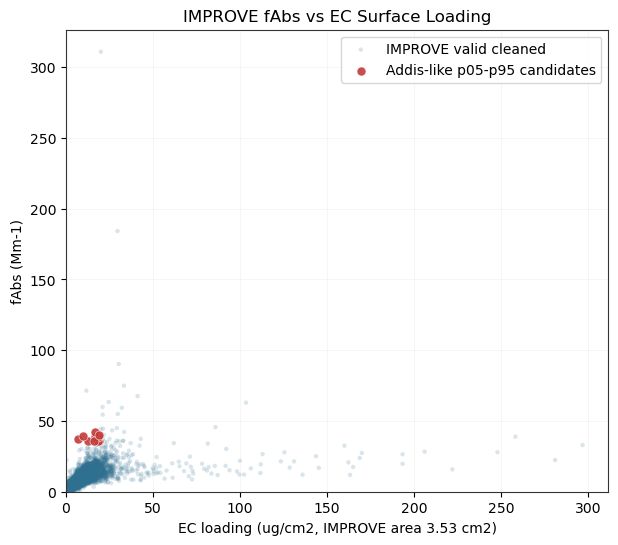

In [5]:
x_col = 'EC_loading_ug_cm2_area_3p53' if 'EC_loading_ug_cm2_area_3p53' in df.columns else 'EC_loading_ug_cm2_primary'
plot_df = df[[x_col, 'fAbs_Val']].dropna()
candidate_plot_df = candidate_df[[x_col, 'fAbs_Val']].dropna() if (not candidate_df.empty and x_col in candidate_df.columns) else pd.DataFrame()

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(plot_df[x_col], plot_df['fAbs_Val'], s=10, alpha=0.18, color='#2F6F8F', edgecolor='none', label='IMPROVE valid cleaned')
if not candidate_plot_df.empty:
    ax.scatter(candidate_plot_df[x_col], candidate_plot_df['fAbs_Val'], s=42, alpha=0.9, color='#C43B3B', edgecolor='white', linewidth=0.4, label='Addis-like p05-p95 candidates')
ax.set_xlabel('EC loading (ug/cm2, IMPROVE area 3.53 cm2)')
ax.set_ylabel('fAbs (Mm-1)')
ax.set_title('IMPROVE fAbs vs EC Surface Loading')
set_origin_zero(ax, plot_df[x_col], plot_df['fAbs_Val'])
ax.grid(True, alpha=0.25)
ax.legend(frameon=True)
savefig(fig, 'improve_fabs_vs_ec_surface_loading_origin_zero.png')
plt.show()

## Candidate Table Stub

Use Addis-like flags if they are present in the loaded table. Otherwise this cell writes the highest-fAbs rows with available loading metrics as a placeholder for the next screen.

In [6]:
source_for_candidates = candidate_df if not candidate_df.empty else df
candidate_cols = [c for c in [
    'Date', 'SiteCode', 'SiteName', 'AuxID', 'fAbs_Val', 'ECf_Val', 'OCf_Val', 'MF_Val',
    'volume_m3', 'EC_loading_ug', 'EC_loading_ug_cm2_area_3p53',
    'OC_loading_ug_cm2_area_3p53', 'MF_loading_ug_cm2_area_3p53', 'tau633_from_fAbs',
    'RefI_635_Val', 'TransI_635_Val', 'RefF_635_Val', 'TransF_635_Val', 'RefM_635_Val', 'TransM_635_Val'
] if c in source_for_candidates.columns]

candidates = source_for_candidates[candidate_cols].copy()
if candidates.empty:
    candidates = df.sort_values('fAbs_Val', ascending=False).head(50)[candidate_cols].copy()

candidate_path = OUTPUT_DIR / 'improve_addis_like_candidate_table.csv'
candidates.to_csv(candidate_path, index=False)
print(candidate_path)
display(candidates.head(20))

/Users/ahmadjalil/github/aethmodular/research/improve_hips_offset/next_tests_2026_04/output/improve_addis_like_candidate_table.csv


,Date,SiteCode,SiteName,AuxID,fAbs_Val,ECf_Val,OCf_Val,MF_Val,volume_m3,EC_loading_ug,EC_loading_ug_cm2_area_3p53,OC_loading_ug_cm2_area_3p53,MF_loading_ug_cm2_area_3p53,tau633_from_fAbs,RefI_635_Val,TransI_635_Val,RefF_635_Val,TransF_635_Val,RefM_635_Val,TransM_635_Val
0,2024-02-24,CACR1,Caney Creek,0,37.20,1.03405,7.35518,77.97117,23.021941,23.805838,6.743864,47.968986,508.512095,2.426108,282.41,54.20,526.57,253.09,240.23,8.61
1,2023-11-26,FRES1,Fresno,0,35.81,3.08624,7.55907,44.05920,21.564317,66.552657,18.853444,46.177388,269.151997,2.187587,119.66,4.03,229.60,132.06,109.11,0.00
2,2017-11-24,NOGA1,Nogales,0,35.68,2.18299,4.95806,19.94912,30.182400,65.887877,18.665121,42.392677,170.570062,3.050731,182.10,6.11,423.91,265.15,164.38,3.05
3,2024-01-25,NOGA1,Nogales,0,35.82,1.81264,4.52602,25.17186,24.985760,45.290188,12.830082,32.035708,178.169420,2.535382,246.44,18.83,517.82,293.09,232.81,5.14
4,2024-12-20,NOGA1,Nogales,0,38.86,2.15927,13.03481,39.71898,29.768400,64.278013,18.209069,109.922220,334.949146,3.277054,192.86,0.46,476.17,209.53,168.43,0.01
5,2016-01-01,PHOE1,Phoenix,0,38.84,2.12336,19.51490,69.61384,28.004400,59.463423,16.845162,154.816732,552.264538,3.081277,121.99,1.40,306.02,174.01,112.55,-0.79
6,2025-01-01,PHOE1,Phoenix,0,42.09,1.93412,15.77267,82.86610,30.085200,58.188387,16.483962,134.426043,706.244530,3.587213,230.61,1.93,514.95,91.58,215.44,0.00
7,2016-01-01,PHOE5,Phoenix Colocated Sampler,0,35.60,1.98111,18.89960,69.26194,28.479600,56.421220,15.983349,152.479617,558.796699,2.872164,215.56,1.82,461.72,235.76,199.90,1.25
8,2024-04-24,SHMI1,Shamrock Mine,0,39.10,2.15766,30.48398,165.33778,15.965854,34.448884,9.758891,137.876138,747.807030,1.768456,530.63,14.01,703.26,217.61,500.22,0.50
9,2023-11-02,SYCA2,Sycamore Canyon,0,40.27,3.98861,47.56307,127.98633,16.640076,66.370775,18.801919,224.207680,603.315096,1.898289,213.93,18.75,480.81,298.91,196.14,5.29
